# 1.老虎机问题

## 1.3 老虎机算法

### 1.3.2 求平均值的实现
$$
Q_n = \frac{R_1+R_2+...+R_n}{n}
$$
- $Q_n$表示执行了$n$次行动后行动价值的估计值
- $R_1,R_2,...,R_n$表示这种情况下实际获得的奖励
- $n$玩家玩老虎机的次数

In [3]:
# 样本均值计算
import numpy as np
np.random.seed(0)
rewards = []
for i in range(1, 11):
    reward = np.random.rand()
    rewards.append(reward)
    Q = sum(rewards) / i
    print(Q)

0.5488135039273248
0.6320014351498722
0.6222554154571294
0.6029123573420713
0.567060845741438
0.5801997236289743
0.5598265075766483
0.6013198192273272
0.6415801460355164
0.6157662833145425


上述代码的问题是随着次数n增加，rewards内元素增加，代码中sum(rewards)的计算量增加，占用内存和计算量都会增加  

解决方法是关注第$n-1$次行动价值的估计值$Q_{n-1}$

$$
Q_{n-1} = \frac{R_1+R_2+...+R_{n-1}}{n-1}
$$

$$
R_1+R_2+...+R_{n-1} = (n-1) Q_{n-1}
$$

由$
Q_n = \frac{R_1+R_2+...+R_{n-1}+R_n}{n}
$得到

$$
Qn = \frac{1}{n}[(n-1)Q_{n-1}+R_n]
$$

$$
Qn = (1-\frac{1}{n})Q_{n-1}+\frac{1}{n}R_n
$$

$$
Qn = Q_{n-1} + \frac{1}{n}(R_n - Q_{n-1})
$$

In [4]:
# 增量式实现
Q = 0
for i in range(1, 11):
    reward = np.random.rand()
    Q += (reward - Q) / i
    print(Q)

0.7917250380826646
0.6603099789177845
0.6295548396431672
0.7035652893055406
0.5770594430840099
0.49540441918693173
0.4275207017945595
0.4781580947637318
0.5114912787844116
0.5473433657306523


### 1.3.3 玩家策略
贪婪行动——不考虑将来，而完全使用之前的游戏经验来选择最佳机器

- 利用：利用目前实际的游戏结果，玩那些看起来最好的老虎机
- 探索：为了老虎机的价值做出更准确的估计，尝试不同的老虎机

为了平衡利用和探索，人们采用$\epsilon-greedy$算法，在不同概率间判断探索还是利用

## 1.4 老虎机算法的实现

### 1.4.1 老虎机的实现

In [2]:
import numpy as np

class Bandit:
    def __init__(self, arms=10): # arms等于老虎机臂的数量，等于老虎机的台数
        self.rates = np.random.rand(arms) # 每台机器的胜率
    
    def play(self, arm):
        rate = self.rates[arm]
        if rate > np.random.rand(): # 比例与一个随机数比大小，假如比例为0.7，则有70%概率赢得游戏
            return 1
        else:
            return 0
        
bandit = Bandit()

for i in range(3):
    print(bandit.play(0))

0
0
0


### 1.4.2 智能代理的实现

In [3]:
bandit = Bandit()
Q = 0

for i in range(1, 11):
    reward = bandit.play(0) # 玩第0台老虎机
    Q += (reward - Q) / i
    print(Q)

0.0
0.0
0.0
0.25
0.4
0.5
0.4285714285714286
0.375
0.3333333333333333
0.4


In [11]:
bandit = Bandit()
Qs = np.zeros(10)
ns = np.zeros(10)

for i in range(10):
    action = np.random.randint(0, 10) 
    reward = bandit.play(action) # 随机玩1-10号机

    ns[action] += 1 # 该号机游玩次数加1
    Qs[action] += (reward - Qs[action]) / ns[action] # 该号机的估计值
    print(Qs)


[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
[1. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
[1. 1. 0. 0. 0. 1. 0. 0. 0. 0.]
[1. 1. 0. 0. 0. 1. 0. 1. 0. 0.]
[1.  0.5 0.  0.  0.  1.  0.  1.  0.  0. ]
[1.  0.5 0.  0.  0.  1.  0.  1.  0.  0. ]
[1.  0.5 0.  0.  0.  1.  0.  1.  0.  0. ]
[1.  0.5 0.  0.  0.  1.  0.  1.  0.  0. ]
[1.  0.5 1.  0.  0.  1.  0.  1.  0.  0. ]
[1.  0.5 1.  0.  0.  1.  0.  1.  0.  1. ]


In [12]:
class Agent:
    def __init__(self, epsilon, action_size=10):
        self.epsilon = epsilon
        self.Qs = np.zeros(action_size)
        self.ns = np.zeros(action_size)

    def update(self, action, reward):
        self.ns[action] += 1
        self.Qs[action] += (reward - self.Qs[action]) / self.ns[action]

    def get_action(self):
        if np.random.rand() < self.epsilon: # 如果随机数小于epsilon概率就探索
            return np.random.randint(0, len(self.Qs)) # 盲选0-9——选择0-9号老虎机
        return np.argmax(self.Qs) # 否则则找老虎机估计值列表中最优（数值最大）的那台老虎机作为经验里最优老虎机使用

### 1.4.3 尝试运行

907


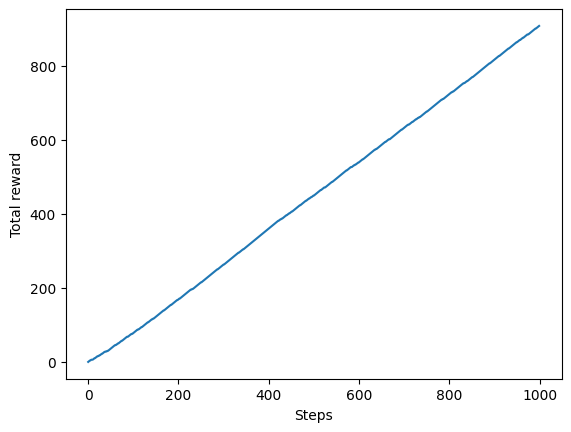

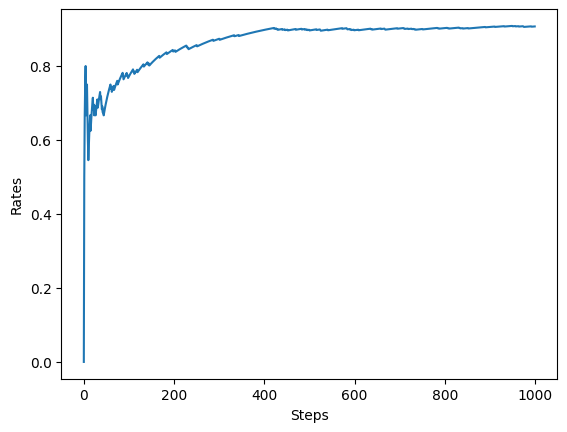

In [13]:
import matplotlib.pyplot as plt
steps = 1000
epsilon = 0.1

bandit = Bandit()
agent = Agent(epsilon)
total_reward = 0
total_rewards = []
rates = []

for step in range(steps):
    action = agent.get_action()  # 选择行动
    reward = bandit.play(action) # 实际去玩，获得奖励
    agent.update(action, reward) # 从行动和奖励中学习
    total_reward += reward
    
    total_rewards.append(total_reward)
    rates.append(total_reward / (step+1))

print(total_reward)

# 图形的绘制(1)
plt.ylabel('Total reward')
plt.xlabel('Steps')
plt.plot(total_rewards)
plt.show()

# 图形的绘制(2)
plt.ylabel('Rates')
plt.xlabel('Steps')
plt.plot(rates)
plt.show()

## 1.5 非稳态问题
以上关于老虎机的问题而言，其每台机器设定的胜率保持固定

In [ ]:
# 稳态老虎机
class Bandit:
    def __init__(self, arms=10):
        self.rates = np.random.rand(arms) # 一旦设置，就不再改变

    def play(self, arm):
        rate = self.rates[arm]
        if rate > np.random.ramd():
            return 1
        else:
            return 0
        
# 非稳态老虎机
class NonStatBandit:
    def __init___(self, arms=10):
        self.arms = arms
        self.rates = np.random.rand(arms)

    def play(self, arm):
        rate = self.rates[arm]
        self.rates += 0.1 * np.random.randn(self.arms) # 添加噪声，每次运行每台老虎机概率都会变化
        if rate > np.random.rand():
            return 1
        else:
            return 0

### 1.5.2 解决非稳态问题前的准备工作
样本均值的$\frac{1}{n}$可以看作每个奖励的权重
$$
Q_n = \frac{R_1+R_2+...+R_n}{n}
$$
变为
$$
Q_n = Q_{n-1} + \frac{1}{n}(R_n-Q_{n-1})
$$
将步长$\frac{1}{n}$变为固定值$\alpha$，当按固定值$\alpha$更新时，过去获得的奖励越久远，奖励的权重沿指数级减少
$$
Q_n = Q_{n-1} + \alpha(R_n-Q_{n-1})
$$
如此权重就可用于非稳态问题  
更清晰地讲  
$$ 
Q_n = \alpha R_n + (1-\alpha)Q_{n-1}
$$
$$=\alpha R_n + (1-\alpha)[\alpha R_{n-1} + (1-\alpha)Q_{n-2}]$$
$$=\alpha R_n + \alpha (1-\alpha)R_{n-1} + (1-\alpha)^2Q_{n-2}$$
$$=\alpha R_n + \alpha (1-\alpha)R_{n-1} + (1-\alpha)^2Q_{n-2} + (1-\alpha)^3Q_{n-3}$$
$$...$$
$$Q_n = \alpha R_n + \alpha(1-\alpha)R_{n-1} + ... + \alpha(1-\alpha)^{n-1}R_1 + (1-\alpha)^nQ_0$$

In [1]:
class AlphaAgent:
    def __init__(self, epsilon, alpha, actions=10):
        self.epsilon = epsilon
        self.Qs = np.zeros(actions)
        self.alpha = alpha

    def update(self, action, reward):
        # 用alpha更新
        self.Qs[action] += (reward - self.Qs[action] * self.alpha)

    def get_action(self):
        if np.random.rand() < self.epsilon:
            return np.random.randint(0, len(self.Qs))
        return np.argmax(self.Qs)